#FirstName LastName (SIS ID#)

# ECI 115: Homework 6

## <font color='red'>**Problem 25.21**</font>

The logistic model is used to simulate population, as in

$\frac{dp}{dt}=k_{gm}(1-p/p_{max})p$

where $p=$ population, $k_{gm}=$ the maximum growth rate under unlimited conditions, and $p_{max}=$ the carrying capacity. Simulate the world's population from 1950 to 2000 using one of the numerical methods described in this chapter. Employ the following initial conditions and parameter values for your simulation: $p_0$ (in 1950) = 2555 million people, $k_{gm}=$ 0.026/yr, and $p_{max}=$ 12,000 million people. Have the function generate output corresponding to the dates for the following measured population data. Develop a plot of your simulation along with these data.

| _t_ | 1950 | 1960 | 1970 | 1980 | 1990 | 2000 |
|:---:|:----:|:----:|:----:|------|------|------|
| _p_ | 2555 | 3040 | 3710 | 4455 | 5275 | 6080 |

<font color='red'> **TL;DR**:
Explain how the 4th-Order Runge-Kutta method works and create a program that uses this method to approximate population growth using the initial conditions specified above. Create a plot that compares the simulated population as a function of time to the actual population values as a function of time provided in the table above. Discuss how the numerical model compares to the tabulated data.
</font>

### <font color='blue'>**Solution 25.21**</font>

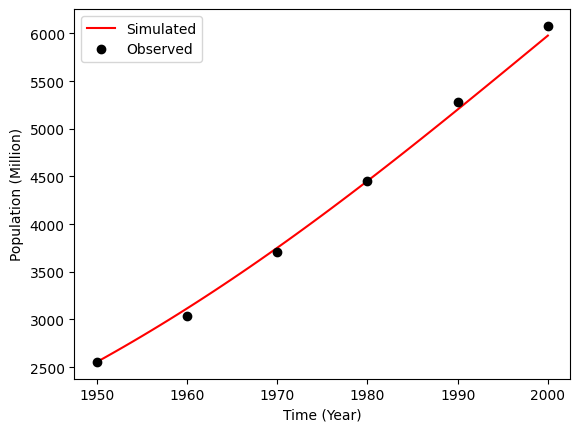

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# we can first use RK4 method
def RK4(f,y0,xmin,xmax,h):
  x = np.arange(xmin,xmax+h,h)
  y = np.zeros(len(x))

  y[0] = y0
  for i in range(len(x)-1):
    k1 = f(x[i], y[i])  #euler slope
    k2 = f(x[i] + h/2, y[i] + k1 * h/2) #midpoint slope using k1
    k3 = f(x[i] + h/2, y[i] + k2 * h/2) #midpoint slope using k2
    k4 = f(x[i] + h, y[i] + k3 * h)  #complete step using k3
    phi = (k1 + 2*k2 + 2*k3 + k4) / 6  #calculating weighted average here
    y[i+1] = y[i] + phi * h

  nfe = len(x) * 4 # 4 function evaluations per step
  return x,y,nfe

k_gm = 0.026
p_max = 12000
p0 = 2555
dt = 1

def dpdt(t, p):
    return k_gm*(1-p/p_max)*p

t, p, nfe = RK4(dpdt, p0, 1950, 2000, dt)

 # observed data
t_row = np.array([1950,1960,1970,1980,1990,2000])
p_row = np.array([2555,3040,3708,4454,5276,6079])

plt.plot(t,p, 'r', label='Simulated');
plt.plot(t_row,p_row, 'o', color='k', label='Observed');
plt.legend()
plt.xlabel('Time (Year)');
plt.ylabel('Population (Million)');
plt.show()

**Discussion of Results**

[Provide discussion here]

## <font color='red'>**Problem 28.40**</font>

The following ODEs have been proposed as a model of an epidemic:

$\frac{dS}{dt}=-\alpha SI$

$\frac{dI}{dt}=\alpha SI-rI$

$\frac{dR}{dt}=rI$

where $S=$ the susceptible individuals, $I=$ the infected, $R=$ the recovered, $a=$ the infection rate, and $r=$ the recovery rate. A city has 10,000 people, all of whom are susceptible.

(a) If a single infectious individual enters the city at $t=$ 0, compute the progression of the epidemic until the number of infected individuals falls below 10. Use the following parameters: $a=$ 0.002/(person $\cdot$ week) and $r=$ 0.15/d. Develop time-series plots of all the state variables. Also generate a phase-plane plot of $S$ versus $I$ versus $R$.

(b) Suppose that after recovery, there is a loss of immunity that causes recovered individuals to become susceptible. This reinfection mechanism can be computed as $\rho R$, where $\rho=$ the reinfection rate. Modify the model to include this mechanism and repeat the computations in (a) using $\rho=$ 0.0015/d.

<font color='red'> **TL;DR**:
Explain how the three ODEs described in the problem statement are interrelated and how these ODEs would change if reinfection were to be incorporated. Create programs that simulates the values of the various populations (i.e., $S$, $I$, $R$) into scenarios: (a) without reinfection and (b) with reinfection (Hint: use the `scipy.integrate.solve_ivp` package to solve these initial value problems). For each part, have your program produced two plots: (1) a 2D plot of $S$, $I$, $R$ vs. $t$ and (2) a 3D plot of $S$ vs. $I$ vs. $R$. Discuss the physical interpretation of what occurs for part (a) and (b) based on the plotted results.

If you want to challenge yourself, create an interactive 3D phase plot to see how $S$, $I$ and $R$ interact with one another. You can use the `plotly.graph_objects` library.
</font>

### <font color='blue'>**Solution 28.40**</font>

In [ ]:
# use built-in ODE solver for a system of equations
import scipy.integrate
r = 0.15 * 7 # convert to 1/week
a = 0.002 # per person per week
# (or convert a to days)

def dydt(t,y):
  return [-a*y[0]*y[1], a*y[0]*y[1] - r*y[1], r*y[1]]

sol = scipy.integrate.solve_ivp(dydt,
                                t_span=[0, 10],
                                y0=[10000, 1, 0],
                                rtol=1e-6)
plt.plot(sol.t, sol.y.T)
plt.xlabel('Time (weeks)')
plt.ylabel('Population')
plt.legend(['Susceptible', 'Infected', 'Recovered'])
plt.show()

# phase plot
ax = plt.figure().add_subplot(projection='3d')
ax.plot(sol.y[0,:], sol.y[1,:], sol.y[2,:])
ax.set_xlabel('Susceptible')
ax.set_ylabel('Infected')
ax.set_zlabel('Recovered')
plt.show()

#part b
# repeat with reinfection rate rho*R
rho = 0.015 * 7 # convert to 1/week

def dydt(t,y):
  return [-a*y[0]*y[1], a*y[0]*y[1] - r*y[1] + rho*y[2], r*y[1] - rho*y[2]]

sol = scipy.integrate.solve_ivp(dydt,
                                t_span=[0, 10],
                                y0=[10000, 1, 0],
                                rtol=1e-6)

plt.plot(sol.t, sol.y.T)
plt.xlabel('Time (weeks)')
plt.ylabel('Population')
plt.legend(['Susceptible', 'Infected', 'Recovered'])
plt.show()


# phase plot
ax = plt.figure().add_subplot(projection='3d')
ax.plot(sol.y[0,:], sol.y[1,:], sol.y[2,:])
ax.set_xlabel('Susceptible')
ax.set_ylabel('Infected')
ax.set_zlabel('Recovered')
plt.show()

**Discussion of Results**

[Provide discussion here]

## <font color='red'>**Problem 28.53**</font>

A forced damped spring-mass system (Fig. P28.53) has the following ordinary differential equation of motion:

$m\frac{d^2x}{dt^2}+a\Big|\frac{dx}{dt}\Big|\frac{dx}{dt}+kx=F_o sin(\omega t)$

where $x=$ displacement from the equilibrium position, $t=$ time, $m=$ 2 kg mass, $a=$ 5 N/(m/s)$^2$, and $k=$ 6 N/m. The damping term is non-linear and represents air damping. The forcing function $F_o sin(\omega t)$ has values of $F_o=$ 2.5 N and $\omega=0.5\ rad/sec$. The initial conditions are

*   *Initial velocity*: $\frac{dx}{dt}=$ 0 m/s
*   *Initial displacement*: $x=$ 1 m

Solve this equation using a numerical method over the time period 0 $\le$ t $\le$ 15 s. Plot the displacement and velocity versus time, and plot the forcing function on the same curve. Also, develop a separate plot of velocity versus displacement.

<p align="center">
  <img src="https://github.com/cdefinnda/ECI-115_HW-Images/blob/main/HW6_Fig.P28.53.png?raw=true" alt="Fig. P28.53" width=500>
</p>

<font color='red'> **TL;DR**:
Explain what forces are being accounted for in the forced damped spring-mass system and how the ODE in the problem statement was derived. Create programs that simulates the values of displacement and velocity as a function of time by using `scipy.integrate.solve_ivp` package to solve the ODE above (Hint: it may be helpful to derive the ODE above from the force balance described in the figure). Then create two plots: (1) displacement ($x$), velocity ($dx/dt$), and external forcing ($F_0 sin(\omega t)$) vs. time ($t$), and (2) velocity ($dx/dt$) vs. displacement ($x$). Discuss any trends you see (hint: it may be easier to see trends if you increase $t$ beyond 15 seconds when solving this initial value problem and if you modify your velocity vs. displacement plot so that marker color corresponds with time).
</font>

### <font color='blue'>**Solution 28.53**</font>



In [ ]:
m = 2
a = 5
k = 6
F0 = 2.5
w = 0.5

def dydt(t,y):
    return  [y[1], (1/m)*F0*np.sin(w*t) -(a/m)*np.abs(y[1])*y[1] - (k/m)*y[0]]

sol = scipy.integrate.solve_ivp(dydt,
                                t_span=[0, 15],
                                y0=[1, 0],
                                rtol=1e-6)
plt.plot(sol.t, sol.y.T)
plt.plot(sol.t, F0*np.sin(w*sol.t))
plt.xlabel('Time (s)')
plt.legend(['Displacement (m)', 'Velocity (m/s)', 'Forcing (N)'])
plt.show()

# phase plot
plt.plot(sol.y[0,:], sol.y[1,:])
plt.xlabel('Displacement (m)')
plt.ylabel('Velocity (m/s)')
plt.show()

**Discussion of Results**

[Provide discussion here]

## <font color='red'>**Problem 4.25**</font>

Under laminar flow conditions, the steady-state velocity of a spherical particle settling in a fluid can be computed with *Stokes law*,

$v_s=\frac{g}{18} \big( \frac{\rho_s-\rho_f}{\mu} \big)d^2$

where $g=$ gravitational acceleration (= 981 cm s$^{-2}$), $\rho_s$ and $\rho_f=$ densities of the particle and the fluid, respectively (g cm$^{-3}$), $\mu=$ dynamic viscosity (g cm$^{-1}$ s$^{-1}$), and $d=$ the sphere's diameter (cm). Suppose that you have two types of spherical particles: a phytoplankton cell ($d=$ 30 $\mu$m, $\rho_s=$ 1.027 g cm$^{-3}$) and a silt particle ($d=$ 30 $\mu$m $\rho_s=$ 2.65 g cm$^{-3}$) settling in water ($\mu=0.013$ g cm$^{-1}$ and $\rho_f=0.99973$ g cm$^{-3}$). For each of these particles, (a) compute the settling velocity and (b) perform a first-order error analysis for the settling velocity. For (b) assume that the parameters $\rho_s$, $\rho_f$, $\mu$, and $d$ have uncertainties of $\pm 2\%$ around their mean values.

<font color='red'> **TL;DR**:
Explain how to compute the settling velocity and how to implement a first-order error analysis for various parameters. In part (a), create a program that computes the settling velocity using the equation above for the two particles. In part (b), create a program that solves for the individual errors associated with the parameters $\rho_s$, $\rho_f$, $\mu$, and $d$, as well as the total error (again, for both particles). Discuss the major sources of error for both particles.
</font>

### <font color='blue'>**Solution 4.25**</font>



In [ ]:
# constants
g = 981 # cm/s^=2
u = 0.013 # g/cm/s
pf = 0.99973 # g/cm^3
# function and all partial derivatives

def v(d, ps):
  return g/18 * (ps - pf) / u * d**2

def dvdu(d, ps):
  return -g / 18 * (ps - pf) / u**2 * d**2

def dvdps(d, ps):
  return  g / 18 / u * d**2

def dvdpf(d, ps):
  return -g / 18 / u * d**2

print('Phytoplankton - velocity and error analysis')
d = 0.003 # convert um to cm
ps = 1.027 # g/cm^3

print('Velocity: %0.6f cm/s' % v(d, ps))

#part b
# error contributions from each input
err1 = np.abs(dvdu(d,ps)) * 0.02 * u
err2 = np.abs(dvdps(d,ps)) * 0.02 * ps
err3 = np.abs(dvdpf(d,ps)) * 0.02 * pf
err4 = np.abs(dvdd(d,ps)) * 0.02 * d

print('Error: +/- %0.6f cm/s' % (err1 + err2 + err3 + err4))

for e in [err1, err2, err3, err4]:
print('%0.6f cm/s' % e)
0.001245 cm/s
0.002000 cm/s
0.000754 cm/s
0.002491 cm/s
print('Silt - velocity and error analysis')
d = 0.003 # convert um to cm
ps = 2.65 # g/cm^3
print('Velocity: %0.6f cm/s' % v(d, ps))
# error contributions from each input
err1 = np.abs(dvdu(d,ps)) * 0.02 * u
err2 = np.abs(dvdps(d,ps)) * 0.02 * ps
err3 = np.abs(dvdpf(d,ps)) * 0.02 * pf
err4 = np.abs(dvdd(d,ps)) * 0.02 * d
print('Error: +/- %0.6f cm/s' % (err1 + err2 + err3 + err4))


**Discussion of Results**

[Provide discussion here]